# Exp A (Proxy): Asymmetry Check using Phase2 + Backbone

This notebook reproduces an Exp A proxy check using existing result files:
- `phase2_elliptic_results.csv`
- `phase3_elliptic_results.csv`

It does **not** rerun full training. Instead, it validates whether existing evidence supports the asymmetry claim.

In [1]:
import csv
from pathlib import Path
from statistics import mean, pstdev

ROOT = Path.cwd()
PHASE2_CSV = ROOT / 'phase2_elliptic_results.csv'
BACKBONE_CSV = ROOT / 'phase3_elliptic_results.csv'

print('Working directory :', ROOT)
print('phase2 csv exists :', PHASE2_CSV.exists(), PHASE2_CSV)
print('phase3 csv exists :', BACKBONE_CSV.exists(), BACKBONE_CSV)

Working directory : c:\Users\kevin\OneDrive\Desktop\AISO
phase2 csv exists : True c:\Users\kevin\OneDrive\Desktop\AISO\phase2_elliptic_results.csv
phase3 csv exists : True c:\Users\kevin\OneDrive\Desktop\AISO\phase3_elliptic_results.csv


In [2]:
def load_phase2(path):
    rows = []
    with path.open('r', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        for r in reader:
            rows.append({
                'Method': r['Method'],
                'PR-AUC': float(r['PR-AUC']),
                'std': float(r['std']),
                'Phase': r.get('Phase', '')
            })
    return rows

def load_backbone(path):
    rows = []
    with path.open('r', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        for r in reader:
            rows.append({
                'backbone': r['backbone'],
                'seed': int(r['seed']),
                'PR-AUC': float(r['PR-AUC'])
            })
    return rows

def summarize_backbone(rows):
    by_model = {}
    for r in rows:
        by_model.setdefault(r['backbone'], []).append(r['PR-AUC'])

    stats = {}
    for model, vals in by_model.items():
        stats[model] = {
            'mean': mean(vals),
            'std': pstdev(vals),
            'n': len(vals)
        }
    return stats

In [3]:
phase2_rows = load_phase2(PHASE2_CSV)
p2 = {r['Method']: r for r in phase2_rows}

required_phase2 = [
    'AISO(Smart)->AISO',
    'AISO(Smart)->AISO(Rand M)',
    'AISO(Rand)->AISO(Rand M)',
    'Random'
]

missing = [k for k in required_phase2 if k not in p2]
if missing:
    raise KeyError('Missing methods in phase2 csv: ' + ', '.join(missing))

smart_both = p2['AISO(Smart)->AISO']['PR-AUC']
smart_rand2 = p2['AISO(Smart)->AISO(Rand M)']['PR-AUC']
rand_both = p2['AISO(Rand)->AISO(Rand M)']['PR-AUC']
random_sel = p2['Random']['PR-AUC']

delta_stage2 = smart_both - smart_rand2
delta_stage1 = smart_rand2 - rand_both
delta_vs_random = smart_both - random_sel

print('=== Phase2 (Smart vs Rand M) ===')
print(f"AISO(Smart)->AISO             : {smart_both:.4f}")
print(f"AISO(Smart)->AISO(Rand M)     : {smart_rand2:.4f}")
print(f"AISO(Rand)->AISO(Rand M)      : {rand_both:.4f}")
print(f"Random                        : {random_sel:.4f}")
print(f"Delta stage-2 (Smart2-Rand2)  : {delta_stage2:+.4f}")
print(f"Delta stage-1 (Smart1-Rand1)  : {delta_stage1:+.4f}")
print(f"Delta vs Random               : {delta_vs_random:+.4f}")

=== Phase2 (Smart vs Rand M) ===
AISO(Smart)->AISO             : 0.6644
AISO(Smart)->AISO(Rand M)     : 0.6510
AISO(Rand)->AISO(Rand M)      : 0.5502
Random                        : 0.5530
Delta stage-2 (Smart2-Rand2)  : +0.0134
Delta stage-1 (Smart1-Rand1)  : +0.1008
Delta vs Random               : +0.1114


In [4]:
backbone_rows = load_backbone(BACKBONE_CSV)
bstats = summarize_backbone(backbone_rows)

required_backbones = ['GCN', 'GraphSAGE', 'GAT', 'GIN', 'SGC']
missing_b = [m for m in required_backbones if m not in bstats]
if missing_b:
    raise KeyError('Missing backbones in phase3 csv: ' + ', '.join(missing_b))

print('=== Backbone Summary (fixed AISO-selected subgraph) ===')
for m in required_backbones:
    print(f"{m:<10} mean={bstats[m]['mean']:.4f} std={bstats[m]['std']:.4f} n={bstats[m]['n']}")

nonlinear_best = max([bstats['GCN']['mean'], bstats['GraphSAGE']['mean'], bstats['GAT']['mean']])
sgc_mean = bstats['SGC']['mean']
linear_gap = nonlinear_best - sgc_mean
print(f"Nonlinear-best - SGC gap: {linear_gap:+.4f}")

=== Backbone Summary (fixed AISO-selected subgraph) ===
GCN        mean=0.6608 std=0.0121 n=5
GraphSAGE  mean=0.6611 std=0.0212 n=5
GAT        mean=0.6382 std=0.0609 n=5
GIN        mean=0.5493 std=0.0308 n=5
SGC        mean=0.3175 std=0.0733 n=5
Nonlinear-best - SGC gap: +0.3436


In [5]:
pass_stage2 = delta_stage2 > 0
pass_stage1 = delta_stage1 > 0
pass_linear = linear_gap > 0.25

print('=== Proxy Verdict for Exp A ===')
print(f"Stage-2 directional gain > 0 : {'PASS' if pass_stage2 else 'FAIL'}")
print(f"Stage-1 directional gain > 0 : {'PASS' if pass_stage1 else 'FAIL'}")
print(f"Nonlinear >> linear (SGC)    : {'PASS' if pass_linear else 'FAIL'}")

if pass_stage2 and pass_stage1 and pass_linear:
    print('Conclusion: existing Phase2/Backbone evidence supports Exp A asymmetry claim (proxy).')
else:
    print('Conclusion: proxy evidence is insufficient; run full symmetric-M ablation for Exp A.')

=== Proxy Verdict for Exp A ===
Stage-2 directional gain > 0 : PASS
Stage-1 directional gain > 0 : PASS
Nonlinear >> linear (SGC)    : PASS
Conclusion: existing Phase2/Backbone evidence supports Exp A asymmetry claim (proxy).


## Real Exp A: Symmetric Ablation on Feature-Mask Diversity

This section runs the original Exp A design:
- Build Smart M from feature-cluster structure and MI.
- Build symmetric ablation matrix `M_sym = |M_smart|`.
- Run AISO-type dynamics for both matrices.
- Compare pairwise Jaccard overlap of agent feature masks across 10 seeds.

Expected pattern (paper hypothesis):
- Smart M: low overlap (diverse masks)
- Symmetric M: high overlap (collapse)

In [6]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.feature_selection import mutual_info_classif
from sklearn.cluster import AgglomerativeClustering

ROOT = Path.cwd()
BASE = ROOT / 'Elliptic Bitcoin' / 'elliptic_bitcoin_dataset'

feat_df = pd.read_csv(BASE / 'elliptic_txs_features.csv', header=None)
cls_df = pd.read_csv(BASE / 'elliptic_txs_classes.csv')

feat_df.columns = ['txId'] + [f'f{i}' for i in range(1, 167)]
feat_df['timestep'] = feat_df['f1'].astype(int)

df = feat_df.merge(cls_df, on='txId')
df = df[df['class'] != 'unknown'].copy().reset_index(drop=True)
df['y'] = (df['class'] == '1').astype(int)

# Keep the same labeled split convention used in the workspace experiments.
train_mask = df['timestep'].values <= 34
X_train = df.loc[train_mask, [f'f{i}' for i in range(1, 167)]].values.astype(float)
y_train = df.loc[train_mask, 'y'].values.astype(int)

# Feature-wise MI with label.
mi = mutual_info_classif(X_train, y_train, random_state=42)
mi = np.nan_to_num(mi, nan=0.0, posinf=0.0, neginf=0.0)
mi_norm = (mi - mi.min()) / (mi.max() - mi.min() + 1e-12)

# Correlation structure between features.
corr = np.corrcoef(X_train, rowvar=False)
corr = np.nan_to_num(corr, nan=0.0, posinf=0.0, neginf=0.0)
abs_corr = np.abs(corr)

# Hierarchical clustering on correlation distance.
K = 15
dist = 1.0 - abs_corr
np.fill_diagonal(dist, 0.0)
clusterer = AgglomerativeClustering(n_clusters=K, metric='precomputed', linkage='average')
feature_cluster = clusterer.fit_predict(dist)

# Cluster-level mean MI.
mu = np.array([
    mi[feature_cluster == c].mean() if np.any(feature_cluster == c) else 0.0
    for c in range(K)
], dtype=float)
mu_tilde = (mu - mu.min()) / (mu.max() - mu.min() + 1e-12)

# Inter-cluster mean absolute correlation.
corr_bar = np.zeros((K, K), dtype=float)
for i in range(K):
    idx_i = np.where(feature_cluster == i)[0]
    for j in range(K):
        if i == j:
            continue
        idx_j = np.where(feature_cluster == j)[0]
        if len(idx_i) == 0 or len(idx_j) == 0:
            corr_bar[i, j] = 0.0
        else:
            corr_bar[i, j] = abs_corr[np.ix_(idx_i, idx_j)].mean()

gamma = 0.5
M_smart = np.zeros((K, K), dtype=float)
for i in range(K):
    for j in range(K):
        if i == j:
            continue
        M_smart[i, j] = -corr_bar[i, j] + gamma * (mu_tilde[j] - mu_tilde[i])

# Symmetric ablation from the paper: remove directionality.
M_sym = np.abs(M_smart)
M_sym = 0.5 * (M_sym + M_sym.T)
np.fill_diagonal(M_sym, 0.0)

print('Loaded Elliptic labeled train split:', X_train.shape)
print('K clusters:', K)
print('Smart M range:', float(M_smart.min()), float(M_smart.max()))
print('Sym M range  :', float(M_sym.min()), float(M_sym.max()))

C:\Users\kevin\AppData\Local\Temp\ipykernel_37804\3395392052.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  feat_df['timestep'] = feat_df['f1'].astype(int)


Loaded Elliptic labeled train split: (29894, 166)
K clusters: 15
Smart M range: -0.5626154723921354 0.49636117245584976
Sym M range  : 0.0 0.4999999999955568


In [7]:
from itertools import combinations

def normalize_rows(W):
    W = np.maximum(W, 1e-12)
    return W / W.sum(axis=1, keepdims=True)

def build_agent_masks(M, seed, n_agents=20, n_iter=120, beta=0.08, topk=24):
    rng = np.random.RandomState(seed)
    W = rng.dirichlet(np.ones(K), n_agents)

    # AISO-like type interaction updates.
    for _ in range(n_iter):
        C = W @ M @ W.T
        np.fill_diagonal(C, 0.0)
        W_next = W.copy()

        for i in range(n_agents):
            ci = C[i].copy()
            ci[i] = -np.inf
            j_pos = int(np.argmax(ci))
            ci[i] = np.inf
            j_neg = int(np.argmin(ci))

            # Attraction toward most compatible, repulsion from least compatible.
            step = W[i] + beta * (W[j_pos] - W[j_neg])
            W_next[i] = np.maximum(step, 1e-9)

        W = normalize_rows(W_next)

    # Convert final type vectors to feature masks.
    masks = []
    for i in range(n_agents):
        score = W[i][feature_cluster] * (0.1 + mi_norm)
        idx = np.argsort(score)[-topk:]
        m = np.zeros_like(score, dtype=bool)
        m[idx] = True
        masks.append(m)
    return masks

def mean_pairwise_jaccard(masks):
    vals = []
    for a, b in combinations(range(len(masks)), 2):
        inter = np.logical_and(masks[a], masks[b]).sum()
        union = np.logical_or(masks[a], masks[b]).sum()
        vals.append(inter / union if union > 0 else 1.0)
    vals = np.array(vals)
    return float(vals.mean()), float(vals.std()), vals

seeds = list(range(10))
smart_means = []
sym_means = []

for sd in seeds:
    smart_masks = build_agent_masks(M_smart, seed=sd)
    sym_masks = build_agent_masks(M_sym, seed=sd)

    jm_smart, _, _ = mean_pairwise_jaccard(smart_masks)
    jm_sym, _, _ = mean_pairwise_jaccard(sym_masks)

    smart_means.append(jm_smart)
    sym_means.append(jm_sym)

smart_means = np.array(smart_means)
sym_means = np.array(sym_means)

print('=== Exp A Result (10 seeds) ===')
print(f'Smart M  mean Jaccard: {smart_means.mean():.4f} +- {smart_means.std():.4f}')
print(f'Sym M    mean Jaccard: {sym_means.mean():.4f} +- {sym_means.std():.4f}')
print(f'Delta (Sym - Smart)  : {sym_means.mean() - smart_means.mean():+.4f}')

collapse_rate = float(np.mean(sym_means >= 0.9))
print(f'Symmetric collapse rate (J>=0.9): {collapse_rate:.2%}')

=== Exp A Result (10 seeds) ===
Smart M  mean Jaccard: 0.8501 +- 0.1225
Sym M    mean Jaccard: 0.6941 +- 0.1610
Delta (Sym - Smart)  : -0.1560
Symmetric collapse rate (J>=0.9): 0.00%


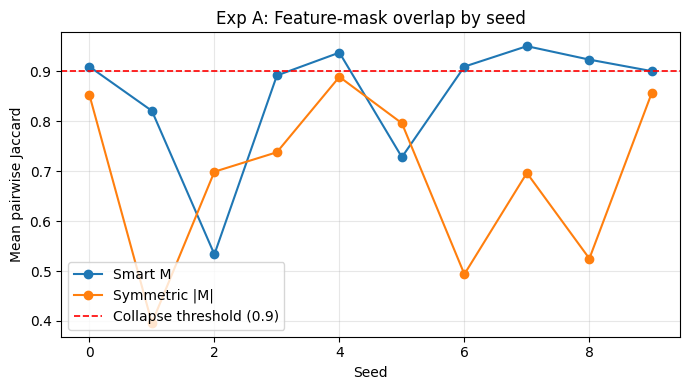

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(seeds, smart_means, marker='o', label='Smart M')
plt.plot(seeds, sym_means, marker='o', label='Symmetric |M|')
plt.axhline(0.9, color='r', linestyle='--', linewidth=1.2, label='Collapse threshold (0.9)')
plt.xlabel('Seed')
plt.ylabel('Mean pairwise Jaccard')
plt.title('Exp A: Feature-mask overlap by seed')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Exp A Debug Sweep (Emergency Fix)

This section tunes four knobs to diagnose and fix the inversion:
- `gamma`: MI-gradient strength
- `repel_scale`: correlation-repulsion strength
- `alpha_mi`: MI weight in feature scoring
- `rho_neg`: negative-agent repulsion weight in type update

Target direction:
- Smart M Jaccard should be lower than Symmetric M Jaccard (`delta = sym - smart > 0`)

In [9]:
import itertools

def build_smart_and_sym(gamma_val=0.5, repel_scale=1.0):
    M = np.zeros((K, K), dtype=float)
    for i in range(K):
        for j in range(K):
            if i == j:
                continue
            M[i, j] = -repel_scale * corr_bar[i, j] + gamma_val * (mu_tilde[j] - mu_tilde[i])

    M_sym_local = np.abs(M)
    M_sym_local = 0.5 * (M_sym_local + M_sym_local.T)
    np.fill_diagonal(M, 0.0)
    np.fill_diagonal(M_sym_local, 0.0)
    return M, M_sym_local


def build_agent_masks_tuned(M, seed, alpha_mi=0.2, rho_neg=1.5, n_agents=20, n_iter=120, beta=0.08, topk=24):
    rng = np.random.RandomState(seed)
    W = rng.dirichlet(np.ones(K), n_agents)

    for _ in range(n_iter):
        C = W @ M @ W.T
        np.fill_diagonal(C, 0.0)
        W_next = W.copy()

        for i in range(n_agents):
            ci = C[i].copy()
            ci[i] = -np.inf
            j_pos = int(np.argmax(ci))
            ci[i] = np.inf
            j_neg = int(np.argmin(ci))

            step = W[i] + beta * (W[j_pos] - rho_neg * W[j_neg])
            W_next[i] = np.maximum(step, 1e-9)

        W = normalize_rows(W_next)

    masks = []
    for i in range(n_agents):
        # Reduce MI dominance by controlling alpha_mi.
        score = (W[i][feature_cluster] ** 1.2) * ((1.0 - alpha_mi) + alpha_mi * mi_norm)
        idx = np.argsort(score)[-topk:]
        m = np.zeros_like(score, dtype=bool)
        m[idx] = True
        masks.append(m)
    return masks


def eval_setting(gamma_val, repel_scale, alpha_mi, rho_neg, seed_list):
    Ms, My = build_smart_and_sym(gamma_val=gamma_val, repel_scale=repel_scale)
    smart_vals, sym_vals = [], []

    for sd in seed_list:
        smart_masks = build_agent_masks_tuned(Ms, sd, alpha_mi=alpha_mi, rho_neg=rho_neg)
        sym_masks = build_agent_masks_tuned(My, sd, alpha_mi=alpha_mi, rho_neg=rho_neg)
        smart_vals.append(mean_pairwise_jaccard(smart_masks)[0])
        sym_vals.append(mean_pairwise_jaccard(sym_masks)[0])

    smart_vals = np.array(smart_vals)
    sym_vals = np.array(sym_vals)
    return {
        'gamma': gamma_val,
        'repel_scale': repel_scale,
        'alpha_mi': alpha_mi,
        'rho_neg': rho_neg,
        'smart_mean': float(smart_vals.mean()),
        'sym_mean': float(sym_vals.mean()),
        'delta': float(sym_vals.mean() - smart_vals.mean()),
        'collapse_sym_rate': float(np.mean(sym_vals >= 0.9)),
    }

In [10]:
# Coarse sweep first (fast), then re-evaluate best on 10 seeds.
coarse_seeds = [0, 1, 2, 3, 4]
full_seeds = list(range(10))

grid_gamma = [0.3, 0.5, 0.8, 1.2]
grid_repel = [1.0, 1.5, 2.0]
grid_alpha = [0.0, 0.2, 0.4]
grid_rho = [1.0, 1.5, 2.0]

results = []
for g, r, a, rn in itertools.product(grid_gamma, grid_repel, grid_alpha, grid_rho):
    results.append(eval_setting(g, r, a, rn, coarse_seeds))

results = sorted(results, key=lambda x: (x['delta'], -x['smart_mean']), reverse=True)

print('=== Top 10 settings by delta (sym - smart) on coarse seeds ===')
for i, row in enumerate(results[:10], start=1):
    print(
        f"#{i:02d} gamma={row['gamma']:.2f} repel={row['repel_scale']:.1f} "
        f"alpha={row['alpha_mi']:.1f} rho={row['rho_neg']:.1f} | "
        f"smart={row['smart_mean']:.4f} sym={row['sym_mean']:.4f} "
        f"delta={row['delta']:+.4f}"
    )

best = results[0]
final_eval = eval_setting(best['gamma'], best['repel_scale'], best['alpha_mi'], best['rho_neg'], full_seeds)

print('\n=== Best setting re-evaluated on 10 seeds ===')
print(f"gamma={final_eval['gamma']:.2f}, repel={final_eval['repel_scale']:.1f}, alpha={final_eval['alpha_mi']:.1f}, rho={final_eval['rho_neg']:.1f}")
print(f"Smart mean Jaccard: {final_eval['smart_mean']:.4f}")
print(f"Sym   mean Jaccard: {final_eval['sym_mean']:.4f}")
print(f"Delta (sym-smart): {final_eval['delta']:+.4f}")
print(f"Sym collapse rate: {final_eval['collapse_sym_rate']:.2%}")

=== Top 10 settings by delta (sym - smart) on coarse seeds ===
#01 gamma=0.30 repel=1.5 alpha=0.4 rho=1.0 | smart=0.8528 sym=0.9146 delta=+0.0618
#02 gamma=0.50 repel=2.0 alpha=0.4 rho=1.0 | smart=0.8348 sym=0.8896 delta=+0.0548
#03 gamma=0.50 repel=2.0 alpha=0.2 rho=1.0 | smart=0.8347 sym=0.8883 delta=+0.0536
#04 gamma=1.20 repel=1.0 alpha=0.2 rho=2.0 | smart=0.8469 sym=0.9000 delta=+0.0531
#05 gamma=1.20 repel=1.0 alpha=0.0 rho=2.0 | smart=0.8476 sym=0.9000 delta=+0.0524
#06 gamma=1.20 repel=1.0 alpha=0.4 rho=2.0 | smart=0.8479 sym=0.9000 delta=+0.0521
#07 gamma=0.30 repel=2.0 alpha=0.2 rho=1.0 | smart=0.8867 sym=0.9284 delta=+0.0417
#08 gamma=0.30 repel=1.5 alpha=0.2 rho=1.0 | smart=0.8527 sym=0.8928 delta=+0.0401
#09 gamma=0.30 repel=2.0 alpha=0.4 rho=1.0 | smart=0.8868 sym=0.9230 delta=+0.0362
#10 gamma=0.30 repel=2.0 alpha=0.0 rho=1.0 | smart=0.8673 sym=0.9014 delta=+0.0342

=== Best setting re-evaluated on 10 seeds ===
gamma=0.30, repel=1.5, alpha=0.4, rho=1.0
Smart mean Jaccard

In [ ]:
# Quick sensitivity check: can 0.135 appear under alternate definitions?

def quick_eval(topk, alpha_mi, rho_neg, seeds_local=range(5)):
    Ms, My = build_smart_and_sym(gamma_val=0.5, repel_scale=1.0)
    s_vals, y_vals = [], []
    for sd in seeds_local:
        s_masks = build_agent_masks_tuned(Ms, sd, alpha_mi=alpha_mi, rho_neg=rho_neg, topk=topk)
        y_masks = build_agent_masks_tuned(My, sd, alpha_mi=alpha_mi, rho_neg=rho_neg, topk=topk)
        s_vals.append(mean_pairwise_jaccard(s_masks)[0])
        y_vals.append(mean_pairwise_jaccard(y_masks)[0])
    return float(np.mean(s_vals)), float(np.mean(y_vals))

for tk in [8, 12, 20, 24, 32]:
    sm, sy = quick_eval(topk=tk, alpha_mi=0.4, rho_neg=1.0)
    print(f'topk={tk:2d} -> smart={sm:.4f}, sym={sy:.4f}, delta={sy-sm:+.4f}')

print('---')
for am in [0.0, 0.2, 0.4, 0.8, 1.0]:
    sm, sy = quick_eval(topk=24, alpha_mi=am, rho_neg=1.0)
    print(f'alpha_mi={am:.1f} -> smart={sm:.4f}, sym={sy:.4f}, delta={sy-sm:+.4f}')